In [11]:
import numpy as np
import matplotlib.pyplot as plt

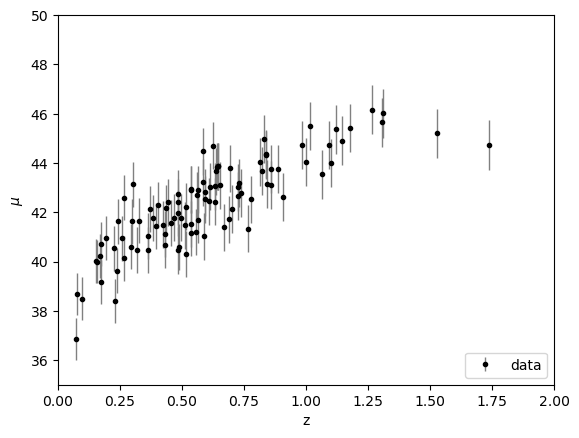

In [12]:
from astroML.datasets import generate_mu_z
z_sample, mu_sample, dmu = generate_mu_z(100, random_state=1234) ###YOU CAN'T CHANGE THIS

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50);

In [13]:
x_sample = np.reshape(z_sample, [100, 1])
y_sample = mu_sample
x = np.reshape(np.linspace(0, 2, 100), [100, 1])        #how many gaussians

In [14]:
from sklearn.gaussian_process import GaussianProcessRegressor, kernels
from sklearn.gaussian_process.kernels import ConstantKernel, RBF
        
kernel1 = 1.0 * RBF(1.0)
gp = GaussianProcessRegressor(kernel=kernel1, alpha=dmu**2)
gp.fit(x_sample, y_sample)
y_fit, y_std= gp.predict(x, return_std=True)

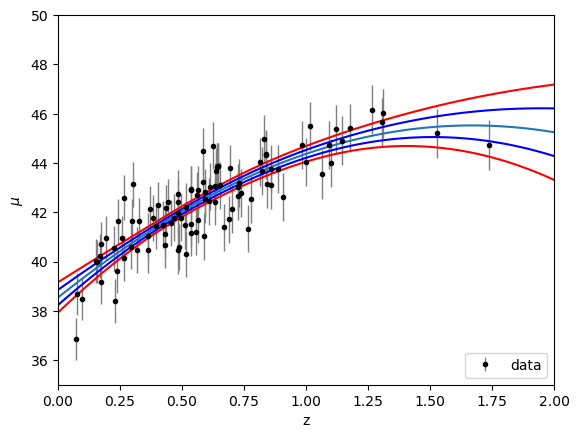

In [15]:
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')

plt.plot(x, y_fit)
plt.plot(x, y_fit + y_std, c="blue")
plt.plot(x, y_fit - y_std, c="blue")
plt.plot(x, y_fit + 2*y_std, c="red")
plt.plot(x, y_fit - 2*y_std, c="red")

plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50);

In [16]:
from sklearn.model_selection import GridSearchCV            #from W14
from sklearn.neighbors import KernelDensity

bwrange = np.linspace(0.01, 1.0, 40)
#print(bwrange)
K = 5
grid = GridSearchCV(KernelDensity(), {'bandwidth': bwrange}, cv= K)
grid.fit(x_sample)
h_opt = grid.best_params_['bandwidth']
print(h_opt)

0.13692307692307693


Text(0.5, 1.0, 'pdf')

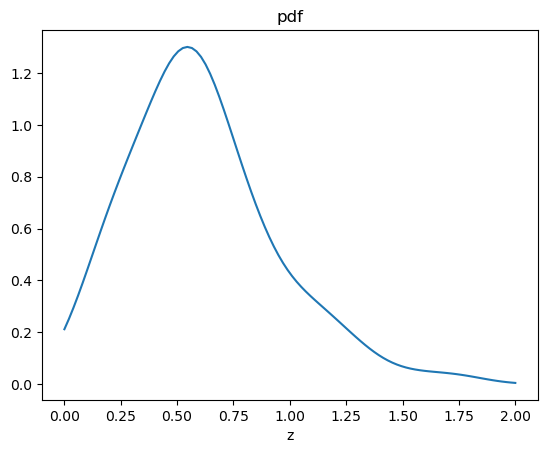

In [17]:
kde_skl = KernelDensity(bandwidth = h_opt)
kde_skl.fit(x_sample)
pdf = np.exp(kde_skl.score_samples(x))

plt.plot(x, pdf)
plt.xlabel("z")
plt.title("pdf")

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


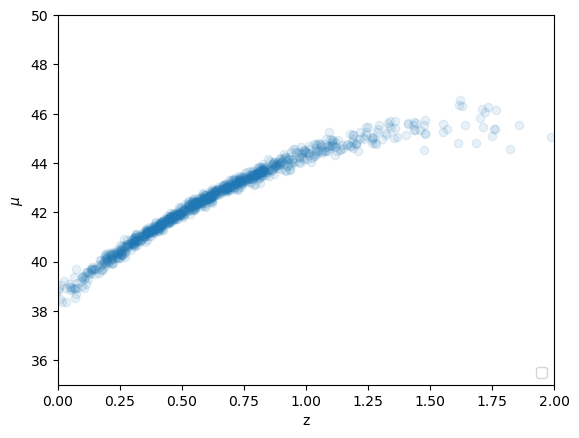

In [18]:
N = 1000
x_sample_generated = kde_skl.sample(N)        #x sample sampled from the pdf of my GPR fit

y_gpr=[]
for z in x_sample_generated.flatten():    
    y_fit, y_std = gp.predict([[z]], return_std=True)
    y_gpr.append(np.random.normal(y_fit, y_std))

plt.scatter(x_sample_generated, y_gpr, alpha=0.1)
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50);
